First 5 Rows
                     Food_Item       Category  Calories (kcal)  Protein (g)  \
0     Scrambled Eggs (2 large)  Protein/Dairy              180         12.0   
1  Whole Wheat Toast (1 slice)          Grain               80          4.0   
2               Coffee (black)       Beverage                5          0.3   
3                       Banana          Fruit              105          1.3   
4        Grilled Chicken Salad   Meal/Protein              350         30.0   

   Carbohydrates (g)  Fat (g)  Fiber (g)  Sugars (g)  Sodium (mg)  \
0                2.0     14.0        0.0         1.0          180   
1               14.0      1.0        2.0         2.0          140   
2                0.0      0.1        0.0         0.0            5   
3               27.0      0.4        3.1        14.0            1   
4               10.0     20.0        5.0         4.0          400   

   Cholesterol (mg)  Meal_Type  Water_Intake (ml)  
0               370  Breakfast               

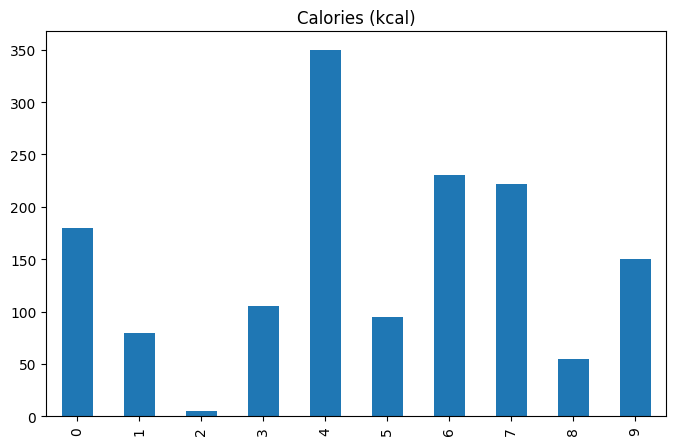

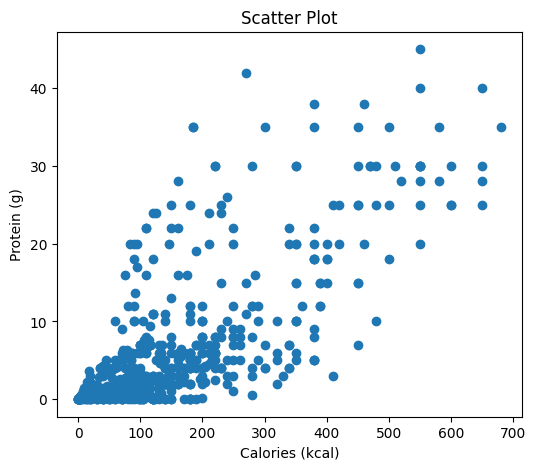

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Read dataset
df = pd.read_csv(
    "daily_food_nutrition_dataset.csv",
    engine="python",
    on_bad_lines="skip"
)

print("First 5 Rows")
print(df.head())

print("\nShape")
print(df.shape)

print("\nData Types")
print(df.dtypes)

print("\nStatistics")
print(df.describe())

# Numerical columns
num_cols = df.select_dtypes(include="number").columns

# Filtering
if len(num_cols) > 0:
    filtered = df[df[num_cols[0]] > df[num_cols[0]].mean()]
    print("\nFiltered Data")
    print(filtered.head())

# Sorting
if len(num_cols) > 0:
    sorted_df = df.sort_values(by=num_cols[0], ascending=False)
    print("\nSorted Data")
    print(sorted_df.head())

# Statistical Analysis
for col in num_cols:
    print("\nColumn:", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Standard Deviation:", df[col].std())

# Grouping
cat_cols = df.select_dtypes(include="object").columns

if len(cat_cols) > 0:
    grouped = df.groupby(cat_cols[0])[num_cols].mean()
    print("\nGrouped Data")
    print(grouped)

# Correlation
if len(num_cols) > 1:
    corr = df[num_cols].corr()
    print("\nCorrelation Matrix")
    print(corr)

# Bar Chart
if len(num_cols) > 0:
    plt.figure(figsize=(8,5))
    df[num_cols[0]].head(10).plot(kind="bar")
    plt.title(num_cols[0])
    plt.show()

# Scatter Plot
if len(num_cols) >= 2:
    plt.figure(figsize=(6,5))
    plt.scatter(df[num_cols[0]], df[num_cols[1]])
    plt.xlabel(num_cols[0])
    plt.ylabel(num_cols[1])
    plt.title("Scatter Plot")
    plt.show()